In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [2]:
X, Y = 20, 200
lattice = Lattice(X, Y)

t = 1
mu = 1.5 * t * np.ones(lattice.X)

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

V_prime = V

F_init =[0.3, -0.3, 0.3j, -0.3j]

H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=None, V=V,
                F_init=F_init)

In [3]:
ky_vals, eigvals = H.spectrum_for_state()

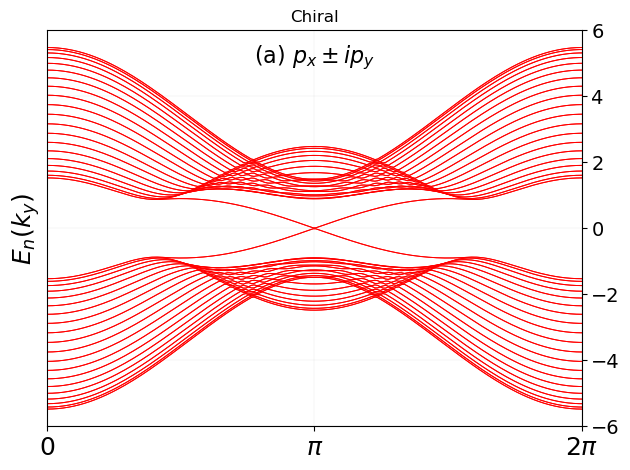

In [4]:
from tkinter import font


for band in eigvals.T:
    plt.plot(ky_vals, band, linewidth=0.7, color='red')
plt.xlim(0, 2 * np.pi)
plt.ylim(-6, 6)
plt.xticks(
    [0, np.pi, 2 * np.pi],
    [r"$0$", r"$\pi$", r"$2\pi$"],
    fontsize=18)
ax = plt.gca()
ax.yaxis.tick_right()
ax.tick_params(axis='y', labelsize=14)

plt.title("Chiral")
plt.grid(True, linewidth=0.2, alpha=0.4)
plt.ylabel(r"$E_n(k_y)$", fontsize=18)
plt.text(np.pi, 5, r"(a) $p_x \pm ip_y$", fontsize=16, ha='center')

plt.tight_layout()
plt.show()


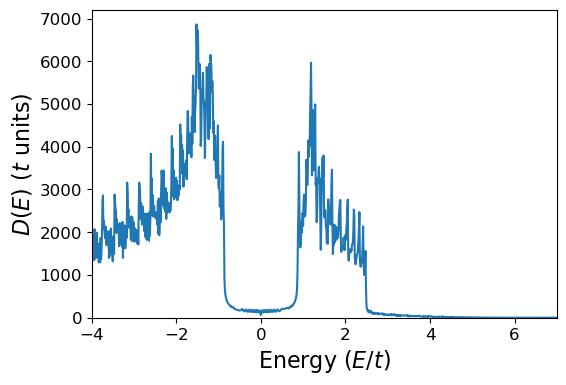

In [5]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)

# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [6]:
text =[
    r"(a) $p_x \pm ip_y$",
    r"(b) $p_x \pm p_y$",
    r"(c) $d_{x^2-y^2}$",
    r"(d) extended-$s$"
]

init_states = [[0.2, -0.2, 0.2j, -0.2j],
               [0.2, -0.2, 0.2, -0.2],
               [0.2, 0.2, -0.2, -0.2],
               [0.2, 0.2, 0.2, 0.2]]

colors = ['red', 'red', 'blue', 'blue']

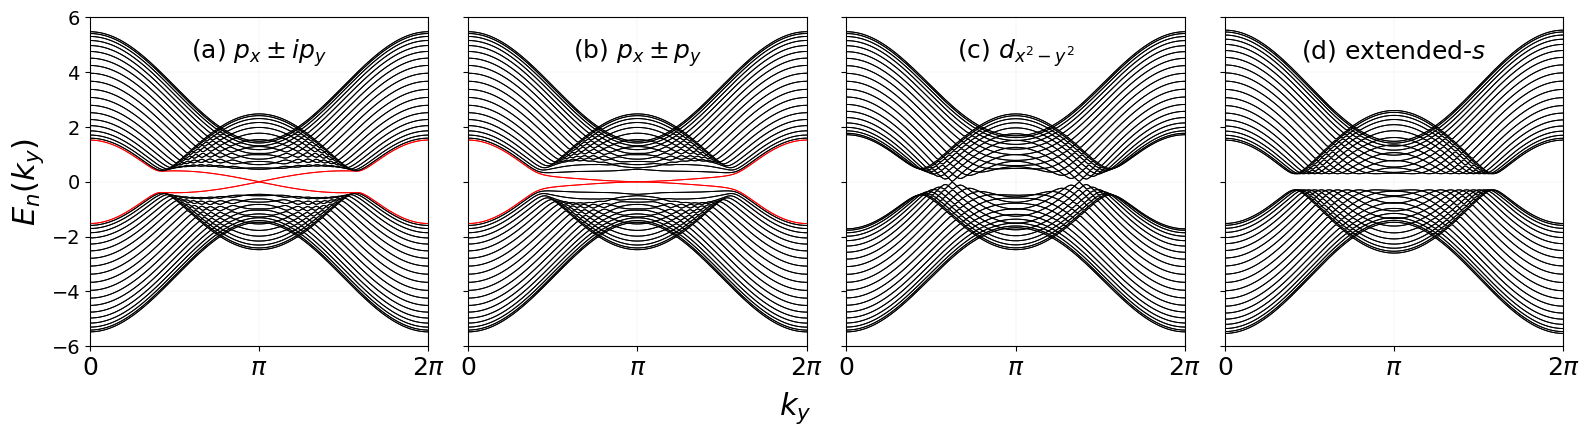

In [7]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
V0 = 2.0 * t / 2 
V = V0 * np.ones(lattice.X)
for i, (state, txt) in enumerate(zip(init_states, text)):
    ax = axs[i]

    H = Hamiltonian(t, mu, lattice, 
                    U=None, V_prime=None, V=V,
                    F_init=state)
    ky_vals, eigvals = H.spectrum_for_state()

    for band in eigvals.T:
        # if band[0] < 0 and band[-1] < 0:
            # continue
        if np.abs(band[len(band)//2]) < 0.31:
            ax.plot(ky_vals, band, linewidth=0.7, color='red')
            continue
        ax.plot(ky_vals, band, linewidth=0.7, color='black')
    ax.text(np.pi, 4.5, txt, fontsize=18, ha='center')
    ax.set_xlim(0, 2 * np.pi)
    ax.set_ylim(-6, 6)

    ax.set_xticks([0, np.pi, 2 * np.pi])
    ax.set_xticklabels([r"$0$", r"$\pi$", r"$2\pi$"], fontsize=18)

    ax.tick_params(axis='y', labelsize=14)

    ax.grid(True, linewidth=0.2, alpha=0.4)

    if i == 0:
        ax.set_ylabel(r"$E_n(k_y)$", fontsize=22)

fig.text(0.5, -0.05, r"$k_y$", ha='center', fontsize=22)
plt.tight_layout()

plt.savefig("../figures/majorana_spectra.pdf", bbox_inches="tight")
plt.show()